# AED — INMET_dataset_agregado.parquet

Análise Exploratória de Dados do parquet gerado pelo notebook de agregação.

Tudo roda em **LazyFrame**: cada seção executa apenas a agregação que precisa,
então isso continua funcionando mesmo com a base completa (dezenas de GB) numa
máquina com pouca RAM. Nenhuma célula faz `.collect()` do dataset inteiro.

**Roteiro**

1. Carga e visão geral
2. Qualidade dos dados — o sentinela `-9999` do INMET
3. Completude por variável
4. Cobertura temporal
5. Cobertura espacial
6. Estatísticas descritivas
7. Ciclo diurno e sazonalidade
8. Resumo dos achados

## 1. Carga e visão geral

In [3]:
import os

# Máquina tem 22 núcleos mas só 15 GB de RAM. Sem limitar isso, o Polars
# paraleliza agressivamente as operações sobre 85M linhas e o pico de memória
# (vários buffers simultâneos) é o suficiente pra travar a máquina inteira.
# Precisa ser setado ANTES de importar polars.
os.environ.setdefault("POLARS_MAX_THREADS", "4")
import polars as pl

ARQUIVO_PARQUET = "INMET_dataset_agregado.parquet"
ARQUIVO_CSV     = "INMET_dataset_agregado.csv"   # fallback

if os.path.exists(ARQUIVO_PARQUET):
    lf_bruto = pl.scan_parquet(ARQUIVO_PARQUET)
    origem = ARQUIVO_PARQUET
elif os.path.exists(ARQUIVO_CSV):
    print("⚠ Parquet não encontrado — usando o CSV.")
    lf_bruto = pl.scan_csv(ARQUIVO_CSV, separator=";", decimal_comma=True,
                           infer_schema_length=None, ignore_errors=True)
    origem = ARQUIVO_CSV
else:
    raise FileNotFoundError(
        f"Nenhum dos arquivos encontrado em {os.path.abspath('.')}:\n"
        f"  - {ARQUIVO_PARQUET}\n  - {ARQUIVO_CSV}"
    )

def tamanho_legivel(caminho):
    b = os.path.getsize(caminho)
    for unid in ("B", "KB", "MB", "GB", "TB"):
        if b < 1024 or unid == "TB":
            return f"{b:.1f} {unid}"
        b /= 1024

print(f"Fonte : {os.path.abspath(origem)}")
print(f"Tamanho em disco: {tamanho_legivel(origem)}")

Fonte : /home/bivolt/Documentos/base-agrega-metereologico/src/INMET_dataset_agregado.parquet
Tamanho em disco: 1.2 GB


> **Nota de escala.** Todos os `.collect()` pesados abaixo usam
> `engine="streaming"`, que processa em lotes em vez de carregar tudo na RAM.
> Como cada um devolve só o resultado de uma agregação (dezenas de linhas), o
> notebook roda igual com 30 mil ou 3 bilhões de registros.

In [4]:
esquema = lf_bruto.collect_schema()

# pl.len() no parquet lê só os metadados de rodapé — não varre os dados
n_linhas = lf_bruto.select(pl.len()).collect().item()

COLS_META = [c for c in ["ANO_REFERENCIA", "ESTACAO", "CODIGO_WMO", "UF", "REGIAO"]
             if c in esquema.names()]

# O parquet grava tudo como String (herdado do CSV original, separador ";",
# vírgula decimal). dtype.is_numeric() não detecta nada aqui — então a lista
# de colunas numéricas é definida por exclusão: tudo que não é meta/data/hora.
COLS_TEXT_REAL = set(COLS_META) | {"DATA (YYYY-MM-DD)", "HORA (UTC)", "Data", "Hora UTC"}
COLS_NUM = [c for c in esquema.names() if c not in COLS_TEXT_REAL]
COLS_TXT = [c for c in esquema.names() if c in COLS_TEXT_REAL]

# vírgula -> ponto e cast pra Float64 (strict=False: o que não parsear vira null)
lf_bruto = lf_bruto.with_columns([
    pl.col(c).str.replace(",", ".", literal=True)
      .cast(pl.Float64, strict=False)
      .alias(c)
    for c in COLS_NUM
])
esquema = lf_bruto.collect_schema()

print(f"Linhas : {n_linhas:,}")
print(f"Colunas: {len(esquema.names())}  ({len(COLS_NUM)} numéricas, {len(COLS_TXT)} texto)")
print(f"\nEsquema:")
for c, dt in esquema.items():
    marca = "meta" if c in COLS_META else ("num " if c in COLS_NUM else "txt ")
    print(f"  [{marca}] {c:<58} {dt}")

Linhas : 85,064,088
Colunas: 27  (18 numéricas, 9 texto)

Esquema:
  [meta] ANO_REFERENCIA                                             String
  [meta] ESTACAO                                                    String
  [meta] CODIGO_WMO                                                 String
  [meta] UF                                                         String
  [meta] REGIAO                                                     String
  [txt ] DATA (YYYY-MM-DD)                                          String
  [txt ] HORA (UTC)                                                 String
  [num ] PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                           Float64
  [num ] PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)      Float64
  [num ] PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)            Float64
  [num ] PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)           Float64
  [num ] RADIACAO GLOBAL (KJ/m²)                                    Float64
  [num ] TEMPERATURA DO AR -

### Dicionário de dados

Descrição de cada uma das 27 colunas do parquet, com significado, unidade e
observações levantadas ao longo desta AED. Completude vem da seção 3; onde não
foi medida (colunas de texto/meta), está marcado como tal.

**Identificação / meta**

| Campo | Significado | Observações |
|---|---|---|
| `ANO_REFERENCIA` | Ano do arquivo INMET de origem do registro. | Usado para agrupar por ano (seção 4). Não é necessariamente igual ao ano da `DATA` do registro em casos de virada de ano. |
| `ESTACAO` | Nome da estação meteorológica (ex.: "AGUA BRANCA"). | 666 estações distintas na base. |
| `CODIGO_WMO` | Código da estação no padrão da Organização Meteorológica Mundial (ex.: "A001") — identificador único e estável, ao contrário do nome. | Preferir para joins/agrupamentos em vez de `ESTACAO`, que pode ter variação de grafia. |
| `UF` | Unidade federativa (estado) onde a estação fica. | 27 UFs cobertas (seção 5). |
| `REGIAO` | Região do Brasil (N, NE, CO, S, SE). | NE e SE concentram a maior parte dos registros. |

**Data e hora — duplicadas por inconsistência de nomenclatura entre anos**

| Campo | Significado | Observações |
|---|---|---|
| `DATA (YYYY-MM-DD)` | Data do registro, ISO, presente nos arquivos INMET mais recentes. | Agora usada na derivação de `DATA` junto com `Data` — ver ✅ abaixo. |
| `HORA (UTC)` | Hora do registro em UTC, arquivos mais recentes (ex.: "1800 UTC"). | Fonte usada para derivar `HORA`/`HORA_LOCAL`. |
| `Data` | Mesma informação de data, mas com nome de coluna dos arquivos INMET mais antigos; formato varia entre anos (`YYYY/MM/DD`, `DD/MM/YYYY`). | Ver ✅ abaixo. |
| `Hora UTC` | Mesma informação de `HORA (UTC)`, nome de coluna dos arquivos mais antigos. | Não usada na derivação de `HORA` (o código pega a primeira coluna cujo nome começa com "HORA"). |
| `DATA` *(derivada)* | Data parseada como `date` do Polars, criada em `lf`. | ✅ **Corrigido nesta sessão**: a célula `c6137a0a` agora faz `coalesce` tentando `DATA (YYYY-MM-DD)` e `Data`, cada uma nos formatos possíveis — antes usava só `Data`, o que deixava nula a data de qualquer ano que só preenchesse a coluna mais nova (explicava os 49.722.168 registros "não reconhecidos" da seção 4). Reexecutar a partir de `c6137a0a` pra ver o novo total. |
| `HORA` / `HORA_LOCAL` *(derivadas)* | Hora inteira 0–23, em UTC e em horário local (UTC−3). | `HORA_LOCAL` foi adicionada nesta sessão pra corrigir o deslocamento de 3h no gráfico de ciclo diurno (seção 7). |

**Variáveis quantitativas**

| Campo | Significado | Unidade | Completude | Observações |
|---|---|---|---|---|
| `TEMPERATURA DO AR - BULBO SECO, HORARIA` | Temperatura do ar no instante da leitura (termômetro comum). | °C | 84,7% | A mais completa da base; usada como `col_temp` nas seções 7–8. |
| `TEMPERATURA MÁXIMA NA HORA ANT. (AUT)` | Temperatura máxima observada na hora anterior (sensor automático). | °C | 84,6% | |
| `TEMPERATURA MÍNIMA NA HORA ANT. (AUT)` | Temperatura mínima observada na hora anterior (sensor automático). | °C | 84,6% | |
| `PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA` | Pressão atmosférica instantânea, ao nível da estação (não corrigida pro nível do mar). | mB (hPa) | 84,6% | Esperado em torno de 900–1030 mB dependendo da altitude da estação. |
| `PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT)` | Pressão máxima na hora anterior. | mB | 84,5% | |
| `PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT)` | Pressão mínima na hora anterior. | mB | 84,5% | |
| `UMIDADE RELATIVA DO AR, HORARIA` | Umidade relativa instantânea. | % | 82,5% | Faixa válida 0–100; qualquer valor fora disso após limpeza do `-9999` indica erro de sensor. |
| `UMIDADE REL. MAX. NA HORA ANT. (AUT)` | Umidade relativa máxima na hora anterior. | % | 82,4% | |
| `UMIDADE REL. MIN. NA HORA ANT. (AUT)` | Umidade relativa mínima na hora anterior. | % | 82,3% | |
| `TEMPERATURA DO PONTO DE ORVALHO` | Temperatura na qual o ar atinge saturação de umidade no instante da leitura. | °C | 82,3% | Sempre ≤ temperatura de bulbo seco; usada com umidade pra estimar conforto térmico. |
| `TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT)` | Ponto de orvalho máximo na hora anterior. | °C | 82,2% | |
| `TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT)` | Ponto de orvalho mínimo na hora anterior. | °C | 82,2% | |
| `VENTO, VELOCIDADE HORARIA` | Velocidade instantânea do vento. | m/s | 81,9% | |
| `VENTO, RAJADA MAXIMA` | Maior rajada de vento na hora. | m/s | 81,8% | Sempre ≥ velocidade horária. |
| `VENTO, DIREÇÃO HORARIA` | Direção de onde o vento sopra. | graus (0–360) | 81,6% | Variável circular — média aritmética não faz sentido (ex.: 359° e 1° são quase iguais, mas a média dá 180°); qualquer agregação futura precisa de média circular. |
| `PRECIPITAÇÃO TOTAL, HORÁRIO` | Chuva acumulada na última hora. | mm | 80,1% | Muitos zeros legítimos (não chove a maior parte do tempo) — não confundir com dado ausente. |
| `RADIACAO GLOBAL (KJ/m²)` | Radiação solar global acumulada na hora. | KJ/m² | 32,6% | Baixa completude porque nem toda estação tem piranômetro (mais comum em automáticas). |
| `RADIACAO GLOBAL (Kj/m²)` | Mesma grandeza que a anterior, mas vinda de arquivos com o cabeçalho grafado em minúsculo ("Kj" em vez de "KJ"). | KJ/m² | 15,6% | ⚠ **Duplicata por inconsistência de maiúsculas/minúsculas** no CSV de origem — provavelmente deveria ser uma coluna só. Somando as duas dá cobertura de radiação mais realista; hoje o `COLS_NUM` conta as duas separadamente, distorcendo a seção 6/violin plot. |

**Achados principais desta análise**

- **`-9999` como sentinela de ausência**: confirmado em 17 das 18 colunas numéricas (seção 2), de 5% a quase 29% dos registros (radiação é a pior). Sem tratar, a média de temperatura cai pra −548°C.
- **Duas colunas duplicadas de radiação** por causa de "KJ" vs "Kj" no cabeçalho — acima.
- ~~**Possível bug na derivação de `DATA`**~~ — corrigido nesta sessão, ver ✅ acima.
- **Direção do vento é variável circular**: agregações lineares (média, desvio-padrão) não são válidas sem conversão pra componentes seno/cosseno.

## 2. Qualidade dos dados — o sentinela `-9999`

O INMET **não deixa a célula vazia** quando o sensor falha: grava `-9999`
(às vezes `-9999.0`). Se isso não for tratado, toda média, mínimo e desvio-padrão
sai destruído — uma temperatura média de −800 °C é o sintoma clássico.

Esta seção mede o problema antes de corrigi-lo.

In [5]:
SENTINELA = -9999.0

contagem_sentinela = (
    lf_bruto
    .select([(pl.col(c) == SENTINELA).sum().alias(c) for c in COLS_NUM])
    .collect(engine="streaming")
)

print(f"Ocorrências de {SENTINELA:g} por variável:\n")
achou = False
for c in COLS_NUM:
    n = contagem_sentinela[c].item()
    if n:
        achou = True
        print(f"  {c:<58} {n:>12,}  ({100*n/n_linhas:5.2f}%)")

if not achou:
    print("  Nenhuma — a base já parece limpa desse sentinela.")
else:
    print("\n⚠ Confirmado: é obrigatório converter para null antes de qualquer estatística.")

Ocorrências de -9999 por variável:

  PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                              5,923,682  ( 6.96%)
  PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)         4,527,358  ( 5.32%)
  PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)               4,549,386  ( 5.35%)
  PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)              4,550,216  ( 5.35%)
  RADIACAO GLOBAL (KJ/m²)                                      24,631,740  (28.96%)
  TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)                  4,356,082  ( 5.12%)
  TEMPERATURA DO PONTO DE ORVALHO (°C)                          4,992,029  ( 5.87%)
  TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)                    4,364,795  ( 5.13%)
  TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)                    4,365,266  ( 5.13%)
  TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)              4,994,537  ( 5.87%)
  TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)              5,023,846  ( 5.91%)
  UMIDADE REL. MAX. NA HORA ANT. (AUT) (

### Efeito no resultado

Comparação lado a lado, na mesma coluna, com e sem o tratamento — para deixar
explícito por que este passo não é opcional.

In [6]:
col_demo = next((c for c in COLS_NUM if "TEMPERATURA DO AR" in c.upper()), None)
if col_demo is None:
    col_demo = COLS_NUM[0] if COLS_NUM else None

if col_demo:
    comp = lf_bruto.select(
        pl.col(col_demo).mean().alias("media_bruta"),
        pl.col(col_demo).min().alias("min_bruto"),
        pl.when(pl.col(col_demo) != SENTINELA).then(pl.col(col_demo))
          .mean().alias("media_tratada"),
        pl.when(pl.col(col_demo) != SENTINELA).then(pl.col(col_demo))
          .min().alias("min_tratado"),
    ).collect(engine="streaming")

    print(f"Coluna: {col_demo}\n")
    print(f"  SEM tratar   -> média {comp['media_bruta'][0]:10.2f} | mínimo {comp['min_bruto'][0]:10.2f}")
    print(f"  COM tratar   -> média {comp['media_tratada'][0]:10.2f} | mínimo {comp['min_tratado'][0]:10.2f}")

Coluna: TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)

  SEM tratar   -> média    -548.25 | mínimo   -9999.00
  COM tratar   -> média      23.40 | mínimo     -51.40


### `lf` — a versão limpa usada daqui pra frente

Substitui `-9999` por `null` em todas as colunas numéricas e deriva as chaves de
tempo (`DATA`, `MES`, `HORA`) a partir das colunas originais. Continua lazy —
nada foi materializado.

In [7]:
# -9999 -> null em todas as numéricas
lf = lf_bruto.with_columns([
    pl.when(pl.col(c) == SENTINELA).then(None).otherwise(pl.col(c)).alias(c)
    for c in COLS_NUM
])

# DATA: o nome da coluna E o formato variam entre os anos do INMET — arquivos
# mais novos usam "DATA (YYYY-MM-DD)", mais antigos usam "Data" (com formato
# variando entre "YYYY/MM/DD" e "DD/MM/YYYY"). Faz coalesce entre as duas
# colunas de origem, não só uma, senão qualquer ano que só preencha a coluna
# nova fica com DATA nula.
COLS_DATA_ORIGEM = [c for c in ["DATA (YYYY-MM-DD)", "Data"] if c in esquema.names()]
if COLS_DATA_ORIGEM:
    tentativas = []
    for c in COLS_DATA_ORIGEM:
        tentativas += [
            pl.col(c).str.to_date("%Y-%m-%d", strict=False),
            pl.col(c).str.to_date("%Y/%m/%d", strict=False),
            pl.col(c).str.to_date("%d/%m/%Y", strict=False),
        ]
    lf = lf.with_columns(
        pl.coalesce(tentativas).alias("DATA")
    ).with_columns(
        pl.col("DATA").dt.month().alias("MES"),
        pl.col("DATA").dt.year().alias("ANO"),
    )

# HORA: "0000 UTC", "00:00", "0000" -> inteiro 0..23
col_hora = next((c for c in esquema.names() if c.strip().upper().startswith("HORA")), None)
if col_hora:
    lf = lf.with_columns(
        pl.col(col_hora).str.extract(r"^\s*(\d{1,2})", 1)
          .cast(pl.Int8, strict=False).alias("HORA")
    )
    # O INMET grava tudo em UTC. Brasil é UTC-3 (a grande maioria das estações,
    # ignorando o horário de verão descontinuado) — sem isso, o ciclo diurno
    # aparece deslocado 3h (ex.: pico de temperatura marcado às 17h em vez de 14h).
    lf = lf.with_columns(
        ((pl.col("HORA") - 3) % 24).alias("HORA_LOCAL")
    )

print("✔ lf pronto (lazy).  Colunas derivadas:",
      [c for c in ["DATA", "ANO", "MES", "HORA", "HORA_LOCAL"] if c in lf.collect_schema().names()])

✔ lf pronto (lazy).  Colunas derivadas: ['DATA', 'ANO', 'MES', 'HORA', 'HORA_LOCAL']


## 3. Completude por variável

Percentual de valores realmente utilizáveis por coluna, já contando o `-9999`
como ausente. É a primeira coisa a olhar: define quais variáveis sustentam
análise e quais estão furadas demais para usar.

In [8]:
completude = (
    lf.select([
        (pl.col(c).count() / pl.len() * 100).alias(c)
        for c in COLS_NUM
    ])
    .collect(engine="streaming")
    .transpose(include_header=True, header_name="variavel", column_names=["completude_pct"])
    .sort("completude_pct", descending=True)
)

with pl.Config(fmt_str_lengths=70, tbl_rows=-1):
    print(completude)

shape: (18, 2)
┌───────────────────────────────────────────────────────┬────────────────┐
│ variavel                                              ┆ completude_pct │
│ ---                                                   ┆ ---            │
│ str                                                   ┆ f64            │
╞═══════════════════════════════════════════════════════╪════════════════╡
│ TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)          ┆ 84.661579      │
│ TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)            ┆ 84.596033      │
│ TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)            ┆ 84.594733      │
│ PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB) ┆ 84.575644      │
│ PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)       ┆ 84.497875      │
│ PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)      ┆ 84.496501      │
│ UMIDADE RELATIVA DO AR, HORARIA (%)                   ┆ 82.458958      │
│ UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)              ┆ 82.402228      │
│ UMIDADE 

### Gráfico — completude por variável

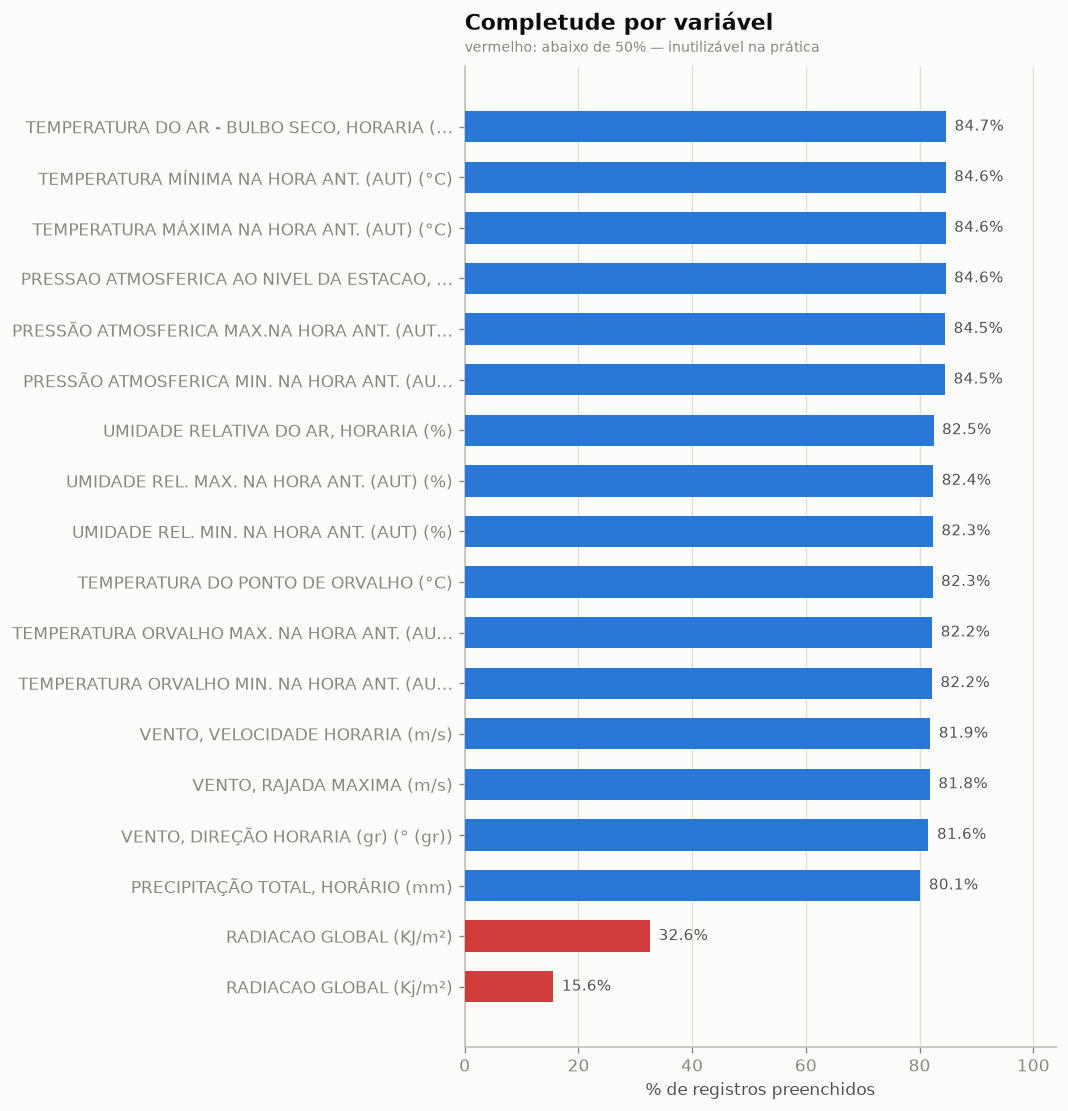

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- paleta (light) ---------------------------------------------------------
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
AZUL      = "#2a78d6"   # slot categórico 1 / hue sequencial
LARANJA   = "#eb6834"   # slot categórico 2
CRITICO   = "#d03b3b"   # status: crítico

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "figure.dpi": 120,
})

def limpar(ax, eixo="y"):
    """Grid recessivo em um eixo só, sem spines supérfluas."""
    ax.grid(True, axis=eixo, zorder=0)
    ax.set_axisbelow(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

def rotulo_curto(nome, n=42):
    return nome if len(nome) <= n else nome[:n-1] + "…"

# --- gráfico ----------------------------------------------------------------
dados = completude.sort("completude_pct")          # menor embaixo -> maior no topo
nomes = [rotulo_curto(v) for v in dados["variavel"].to_list()]
vals  = dados["completude_pct"].to_list()

# emphasis: destaca em vermelho o que está abaixo de 50% (inutilizável na prática)
cores = [CRITICO if v < 50 else AZUL for v in vals]

fig, ax = plt.subplots(figsize=(9, 0.42*len(nomes) + 1.8))
ax.barh(nomes, vals, color=cores, height=0.62, zorder=3)
limpar(ax, eixo="x")
ax.set_xlim(0, 104)
ax.set_xlabel("% de registros preenchidos")

titulo = "Completude por variável"
subtitulo = "vermelho: abaixo de 50% — inutilizável na prática" if any(v < 50 for v in vals) else None
ax.set_title(titulo, loc="left", fontsize=13, fontweight="bold",
             pad=22 if subtitulo else 12)
if subtitulo:
    ax.text(0.0, 1.015, subtitulo, transform=ax.transAxes,
            fontsize=8.5, color=MUTED)

# rótulo direto em cada barra — identidade nunca depende só da cor
for y, v in enumerate(vals):
    ax.text(v + 1.5, y, f"{v:.1f}%", va="center", ha="left",
            fontsize=9, color=INK_2)

plt.tight_layout()
plt.show()

## 4. Cobertura temporal

Quantos registros existem por ano e se há buracos na série.

In [10]:
por_ano = (
    lf.group_by("ANO_REFERENCIA")
      .agg(
          pl.len().alias("registros"),
          pl.col("ESTACAO").n_unique().alias("estacoes"),
      )
      .sort("ANO_REFERENCIA")
      .collect(engine="streaming")
)
print(por_ano)

if "DATA" in lf.collect_schema().names():
    periodo = lf.select(
        pl.col("DATA").min().alias("inicio"),
        pl.col("DATA").max().alias("fim"),
        pl.col("DATA").null_count().alias("datas_nao_parseadas"),
    ).collect(engine="streaming")
    print(f"\nPeríodo: {periodo['inicio'][0]} → {periodo['fim'][0]}")
    nao_ok = periodo["datas_nao_parseadas"][0]
    if nao_ok:
        print(f"⚠ {nao_ok:,} data(s) não reconhecida(s) — verificar formatos extras.")

shape: (26, 3)
┌────────────────┬───────────┬──────────┐
│ ANO_REFERENCIA ┆ registros ┆ estacoes │
│ ---            ┆ ---       ┆ ---      │
│ str            ┆ u32       ┆ u32      │
╞════════════════╪═══════════╪══════════╡
│ 2000           ┆ 25176     ┆ 5        │
│ 2001           ┆ 69528     ┆ 16       │
│ 2002           ┆ 162432    ┆ 33       │
│ 2003           ┆ 449640    ┆ 55       │
│ 2004           ┆ 488112    ┆ 62       │
│ …              ┆ …         ┆ …        │
│ 2021           ┆ 5150880   ┆ 586      │
│ 2022           ┆ 4948920   ┆ 565      │
│ 2023           ┆ 4966920   ┆ 565      │
│ 2024           ┆ 4962960   ┆ 563      │
│ 2025           ┆ 5020248   ┆ 592      │
└────────────────┴───────────┴──────────┘

Período: 2000-05-07 → 2025-12-31


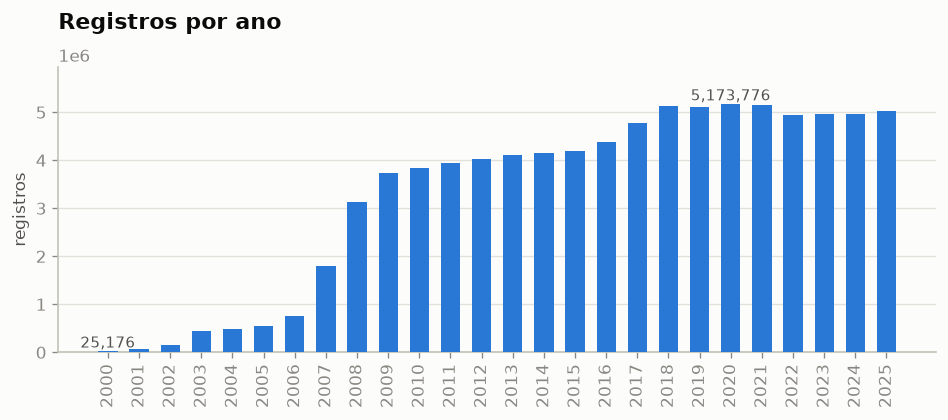

In [11]:
anos = por_ano["ANO_REFERENCIA"].to_list()
regs = por_ano["registros"].to_list()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(anos, regs, color=AZUL, width=0.62, zorder=3)
limpar(ax, eixo="y")
ax.set_ylabel("registros")
ax.set_title("Registros por ano", loc="left", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=90)

# rótulo direto só nas pontas (mínimo e máximo) — não em toda barra
i_min, i_max = regs.index(min(regs)), regs.index(max(regs))
for i in {i_min, i_max}:
    ax.text(i, regs[i], f"{regs[i]:,}", ha="center", va="bottom",
            fontsize=9, color=INK_2)

ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## 5. Cobertura espacial

Distribuição das estações e dos registros por região e UF.

In [12]:
esq_atual = lf.collect_schema().names()

if "REGIAO" in esq_atual:
    por_regiao = (
        lf.group_by("REGIAO")
          .agg(pl.len().alias("registros"),
               pl.col("ESTACAO").n_unique().alias("estacoes"),
               pl.col("UF").n_unique().alias("ufs"))
          .sort("registros", descending=True)
          .collect(engine="streaming")
    )
    print("Por REGIÃO:")
    print(por_regiao)

if "UF" in esq_atual:
    por_uf = (
        lf.group_by("UF")
          .agg(pl.len().alias("registros"),
               pl.col("ESTACAO").n_unique().alias("estacoes"))
          .sort("registros", descending=True)
          .collect(engine="streaming")
    )
    print(f"\nPor UF — {por_uf.height} estado(s):")
    with pl.Config(tbl_rows=15):
        print(por_uf)

if "ESTACAO" in esq_atual:
    n_est = lf.select(pl.col("ESTACAO").n_unique()).collect(engine="streaming").item()
    print(f"\nTotal de estações distintas: {n_est}")

Por REGIÃO:
shape: (5, 4)
┌────────┬───────────┬──────────┬─────┐
│ REGIAO ┆ registros ┆ estacoes ┆ ufs │
│ ---    ┆ ---       ┆ ---      ┆ --- │
│ str    ┆ u32       ┆ u32      ┆ u32 │
╞════════╪═══════════╪══════════╪═════╡
│ NE     ┆ 22089720  ┆ 152      ┆ 9   │
│ SE     ┆ 21318672  ┆ 171      ┆ 4   │
│ CO     ┆ 15462360  ┆ 122      ┆ 4   │
│ S      ┆ 14206128  ┆ 121      ┆ 3   │
│ N      ┆ 11987208  ┆ 102      ┆ 7   │
└────────┴───────────┴──────────┴─────┘

Por UF — 27 estado(s):
shape: (27, 3)
┌─────┬───────────┬──────────┐
│ UF  ┆ registros ┆ estacoes │
│ --- ┆ ---       ┆ ---      │
│ str ┆ u32       ┆ u32      │
╞═════╪═══════════╪══════════╡
│ MG  ┆ 10140960  ┆ 73       │
│ BA  ┆ 7170144   ┆ 50       │
│ RS  ┆ 6809952   ┆ 70       │
│ MT  ┆ 5927112   ┆ 46       │
│ SP  ┆ 5917680   ┆ 46       │
│ MS  ┆ 5033136   ┆ 45       │
│ PA  ┆ 4329984   ┆ 35       │
│ PR  ┆ 3938568   ┆ 27       │
│ …   ┆ …         ┆ …        │
│ AL  ┆ 1055376   ┆ 7        │
│ AC  ┆ 967896    ┆ 7        │

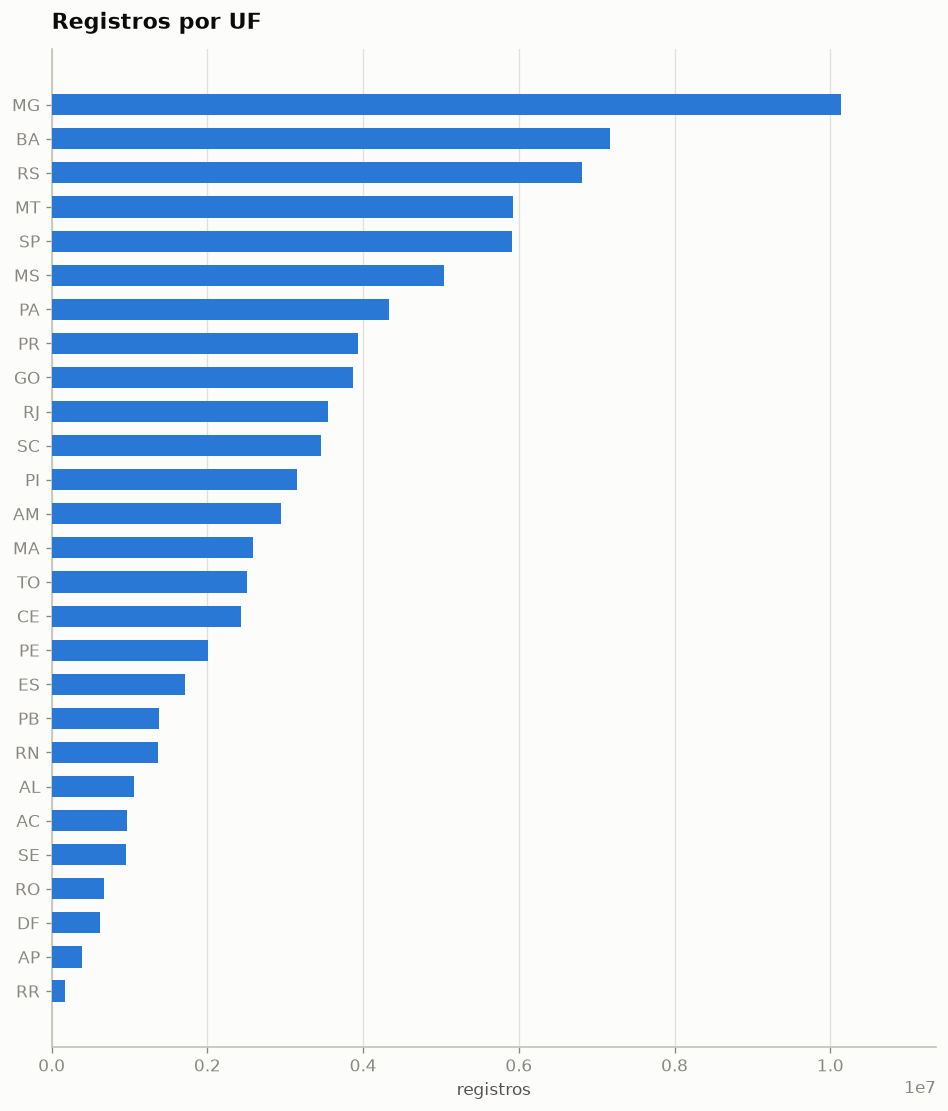

In [13]:
# comparação de magnitude -> uma cor só (sequencial), sem paleta categórica
d = por_uf.sort("registros")
fig, ax = plt.subplots(figsize=(8, 0.28*d.height + 1.8))
ax.barh(d["UF"].to_list(), d["registros"].to_list(),
        color=AZUL, height=0.62, zorder=3)
limpar(ax, eixo="x")
ax.set_xlabel("registros")
ax.set_title("Registros por UF", loc="left", fontsize=13, fontweight="bold", pad=12)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## 6. Estatísticas descritivas

Já com `-9999` fora do cálculo. Vale conferir se cada faixa faz sentido físico
(umidade em 0–100 %, pressão perto de 1013 mB, vento ≥ 0 etc.) — valores fora
disso indicam sentinela remanescente ou erro de unidade.

In [14]:
# Uma coluna por vez: calcular quantile (mediana) exige ordenar a coluna, e
# fazer isso pras 18 colunas numéricas na mesma query soma ~18 x 85M x 8B
# (~12 GB) de buffers de sort simultâneos — o suficiente pra travar uma
# máquina com 15 GB de RAM. Coluna por coluna, o pico fica em ~1 coluna por vez.
linhas = []
for c in COLS_NUM:
    r = (
        lf.select(
            pl.col(c).count().alias("n"),
            pl.col(c).mean().alias("media"),
            pl.col(c).std().alias("desvio"),
            pl.col(c).min().alias("min"),
            pl.col(c).quantile(0.50).alias("mediana"),
            pl.col(c).max().alias("max"),
        )
        .collect(engine="streaming")
    )
    linhas.append({
        "variavel": rotulo_curto(c, 46),
        "n":        r["n"].item(),
        "media":    r["media"].item(),
        "desvio":   r["desvio"].item(),
        "min":      r["min"].item(),
        "mediana":  r["mediana"].item(),
        "max":      r["max"].item(),
    })

tabela = pl.DataFrame(linhas)
with pl.Config(fmt_str_lengths=50, tbl_rows=-1, float_precision=2):
    print(tabela)

shape: (18, 7)
┌─────────────────────────────────────┬──────────┬─────────┬─────────┬────────┬─────────┬──────────┐
│ variavel                            ┆ n        ┆ media   ┆ desvio  ┆ min    ┆ mediana ┆ max      │
│ ---                                 ┆ ---      ┆ ---     ┆ ---     ┆ ---    ┆ ---     ┆ ---      │
│ str                                 ┆ i64      ┆ f64     ┆ f64     ┆ f64    ┆ f64     ┆ f64      │
╞═════════════════════════════════════╪══════════╪═════════╪═════════╪════════╪═════════╪══════════╡
│ PRECIPITAÇÃO TOTAL, HORÁRIO (mm)    ┆ 68171576 ┆ 0.16    ┆ 1.29    ┆ 0.00   ┆ 0.00    ┆ 138.20   │
│ PRESSAO ATMOSFERICA AO NIVEL DA     ┆ 71943500 ┆ 965.20  ┆ 38.07   ┆ 720.10 ┆ 969.90  ┆ 1050.00  │
│ ESTACAO, HORA…                      ┆          ┆         ┆         ┆        ┆         ┆          │
│ PRESSÃO ATMOSFERICA MAX.NA HORA     ┆ 71877347 ┆ 965.47  ┆ 38.10   ┆ 720.30 ┆ 970.20  ┆ 1050.00  │
│ ANT. (AUT) (m…                      ┆          ┆         ┆         ┆      

## 7. Ciclo diurno e sazonalidade

Dois recortes clássicos para checar se os dados são fisicamente plausíveis. As
duas agregações rodam no lazy e devolvem 24 e 12 linhas respectivamente — o
tamanho da base não importa aqui.

In [15]:
col_temp = next((c for c in COLS_NUM if "TEMPERATURA DO AR" in c.upper()), None)
if col_temp is None:
    col_temp = next((c for c in COLS_NUM if "TEMPERATURA" in c.upper()), None)

print(f"Variável usada: {col_temp}")

Variável usada: TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)


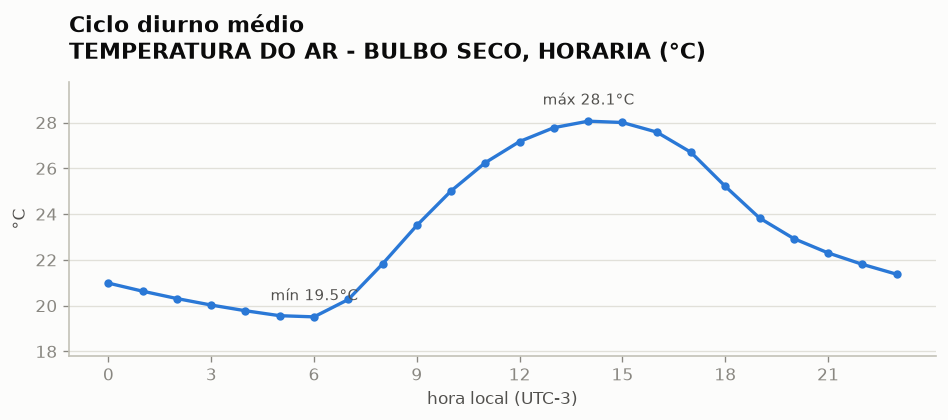

In [16]:
if col_temp and "HORA_LOCAL" in lf.collect_schema().names():
    ciclo = (
        lf.filter(pl.col("HORA_LOCAL").is_not_null() & pl.col(col_temp).is_not_null())
          .group_by("HORA_LOCAL")
          .agg(pl.col(col_temp).mean().alias("media"))
          .sort("HORA_LOCAL")
          .collect(engine="streaming")
    )

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(ciclo["HORA_LOCAL"], ciclo["media"], color=AZUL, linewidth=2,
            marker="o", markersize=4, zorder=3)
    limpar(ax, eixo="y")
    ax.set_xlabel("hora local (UTC-3)")
    ax.set_ylabel("°C")
    ax.set_xticks(range(0, 24, 3))
    ax.set_title(f"Ciclo diurno médio\n{rotulo_curto(col_temp, 46)}",
                 loc="left", fontsize=13, fontweight="bold", pad=14)

    # rótulo direto no pico e no vale
    s = ciclo["media"].to_list(); h = ciclo["HORA_LOCAL"].to_list()
    for idx, txt in ((s.index(max(s)), "máx"), (s.index(min(s)), "mín")):
        ax.annotate(f"{txt} {s[idx]:.1f}°C", (h[idx], s[idx]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, color=INK_2)
    ax.margins(y=0.20)
    plt.tight_layout()
    plt.show()
else:
    print("Sem coluna de temperatura ou de hora — gráfico pulado.")

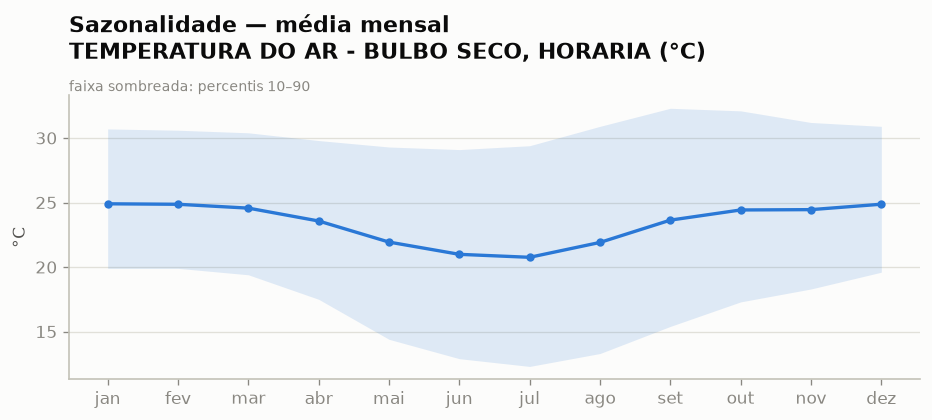

In [17]:
if col_temp and "MES" in lf.collect_schema().names():
    sazonal = (
        lf.filter(pl.col("MES").is_not_null() & pl.col(col_temp).is_not_null())
          .group_by("MES")
          .agg(
              pl.col(col_temp).mean().alias("media"),
              pl.col(col_temp).quantile(0.10).alias("p10"),
              pl.col(col_temp).quantile(0.90).alias("p90"),
          )
          .sort("MES")
          .collect(engine="streaming")
    )

    MESES = ["jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"]
    x = sazonal["MES"].to_list()

    fig, ax = plt.subplots(figsize=(8, 3.6))
    # faixa p10–p90 como contexto recessivo; a média é a série que importa
    ax.fill_between(x, sazonal["p10"], sazonal["p90"],
                    color=AZUL, alpha=0.14, linewidth=0, zorder=2)
    ax.plot(x, sazonal["media"], color=AZUL, linewidth=2,
            marker="o", markersize=4, zorder=3)
    limpar(ax, eixo="y")
    ax.set_xticks(x, [MESES[m-1] for m in x])
    ax.set_ylabel("°C")
    ax.set_title(f"Sazonalidade — média mensal\n{rotulo_curto(col_temp, 46)}",
                 loc="left", fontsize=13, fontweight="bold", pad=22)
    ax.text(0.0, 1.015, "faixa sombreada: percentis 10–90",
            transform=ax.transAxes, fontsize=8.5, color=MUTED)
    plt.tight_layout()
    plt.show()
else:
    print("Sem coluna de mês — gráfico pulado.")

### Distribuição da temperatura

Histograma calculado **no lazy**: a coluna é arredondada para o bin e agrupada,
então só 100-ish linhas voltam para o Python — não os bilhões de valores.

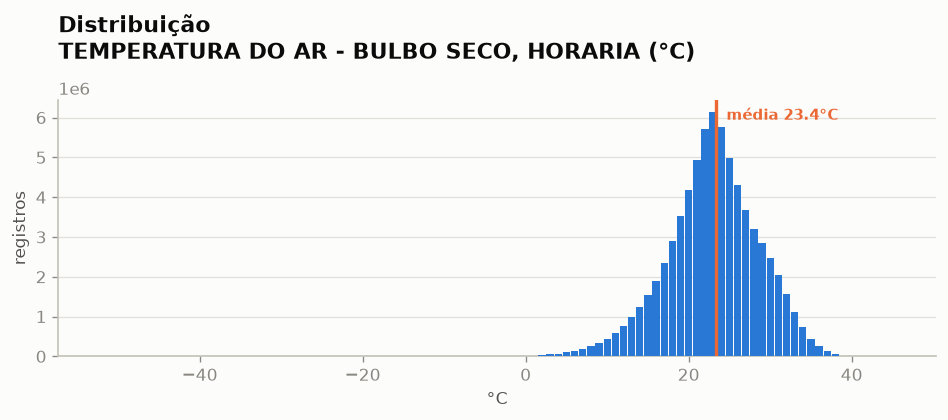

In [18]:
if col_temp:
    LARGURA_BIN = 1.0
    hist = (
        lf.filter(pl.col(col_temp).is_not_null())
          .select((pl.col(col_temp) / LARGURA_BIN).floor() * LARGURA_BIN)
          .group_by(col_temp)
          .agg(pl.len().alias("n"))
          .sort(col_temp)
          .collect(engine="streaming")
    )

    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.bar(hist[col_temp], hist["n"], width=LARGURA_BIN*0.9,
           color=AZUL, zorder=3)
    limpar(ax, eixo="y")
    ax.set_xlabel("°C")
    ax.set_ylabel("registros")
    ax.set_title(f"Distribuição\n{rotulo_curto(col_temp, 46)}",
                 loc="left", fontsize=13, fontweight="bold", pad=14)

    media = lf.select(pl.col(col_temp).mean()).collect(engine="streaming").item()
    ax.axvline(media, color=LARANJA, linewidth=2, zorder=4)
    ax.annotate(f"média {media:.1f}°C", (media, ax.get_ylim()[1]),
                textcoords="offset points", xytext=(6, -12),
                fontsize=9, color=LARANJA, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Violin plot — distribuição das variáveis quantitativas

Compara o formato da distribuição de todas as colunas numéricas num gráfico
só. Como as unidades são muito diferentes entre si (mm, mB, °C, %, m/s,
KJ/m²), cada coluna é padronizada (z-score) antes de plotar — o eixo deixa de
ser a unidade original e passa a ser "desvios-padrão em relação à média".

Com 85M linhas, plotar tudo seria inviável em memória; a amostra abaixo é
determinística (1 a cada N linhas, via `with_row_index`), não aleatória —
suficiente pra ver o formato da distribuição sem materializar a base inteira.

## 8. Resumo dos achados

Fecha a AED com os números que decidem o próximo passo.

In [19]:
print("=" * 68)
print("RESUMO DA AED")
print("=" * 68)

print(f"\nVolume")
print(f"  Registros ............ {n_linhas:,}")
print(f"  Variáveis ............ {len(esquema.names())} ({len(COLS_NUM)} numéricas)")
print(f"  Tamanho em disco ..... {os.path.getsize(origem)/1024**3:.2f} GB")

print(f"\nCobertura")
print(f"  Anos ................. {', '.join(por_ano['ANO_REFERENCIA'].to_list())}")
if "ESTACAO" in esq_atual:
    print(f"  Estações ............. {n_est}")
if "UF" in esq_atual:
    print(f"  UFs .................. {por_uf.height}")

print(f"\nQualidade")
total_sent = sum(contagem_sentinela[c].item() for c in COLS_NUM)
print(f"  Células com -9999 .... {total_sent:,} ({100*total_sent/(n_linhas*len(COLS_NUM)):.2f}% das células numéricas)")

frageis = completude.filter(pl.col("completude_pct") < 50)
if frageis.height:
    print(f"  Variáveis <50% ....... {frageis.height}:")
    for r in frageis.iter_rows(named=True):
        print(f"      • {rotulo_curto(r['variavel'], 52)}  ({r['completude_pct']:.1f}%)")
else:
    print(f"  Variáveis <50% ....... nenhuma")

melhor = completude.head(1)
print(f"  Mais completa ........ {melhor['variavel'][0]} ({melhor['completude_pct'][0]:.1f}%)")
print("\n" + "=" * 68)

RESUMO DA AED

Volume
  Registros ............ 85,064,088
  Variáveis ............ 27 (18 numéricas)
  Tamanho em disco ..... 1.18 GB

Cobertura
  Anos ................. 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025
  Estações ............. 666
  UFs .................. 27

Qualidade
  Células com -9999 .... 103,278,859 (6.75% das células numéricas)
  Variáveis <50% ....... 2:
      • RADIACAO GLOBAL (KJ/m²)  (32.6%)
      • RADIACAO GLOBAL (Kj/m²)  (15.6%)
  Mais completa ........ TEMPERATURA DO AR - BULBO SECO, HORARIA (°C) (84.7%)



## 9. Recortes recomendados para análise

Reaproveita `por_ano`, `por_uf` e `completude` (já coletados nas seções
anteriores — nada aqui faz um novo scan pesado da base) pra responder: em
quais anos, UFs e variáveis os dados são densos o suficiente pra sustentar
uma análise, e onde é preciso ter cautela ou evitar o recorte.

In [20]:
# --- Recorte temporal ---------------------------------------------------
# A rede INMET cresceu de 5 estações (2000) pra 500+ só a partir de meados dos
# 2010s. Um ano com poucas estações não é "menos dado" na mesma proporção do
# Brasil — é uma amostra espacial bem menor e enviesada pras poucas estações
# que existiam. Referência de rede madura = média das estações nos últimos 5
# anos; ano "confiável" = pelo menos 70% dessa rede.
REF_REDE = por_ano["estacoes"].tail(5).mean()
LIMIAR = 0.70

por_ano_flag = por_ano.with_columns(
    (pl.col("estacoes") / REF_REDE >= LIMIAR).alias("rede_madura")
)
primeiro_ano_ok = por_ano_flag.filter(pl.col("rede_madura"))["ANO_REFERENCIA"].min()
fragil = por_ano_flag.filter(~pl.col("rede_madura"))

print(f"Rede de referência (média de estações, últimos 5 anos): {REF_REDE:.0f}")
print(f"Primeiro ano com >= {LIMIAR:.0%} dessa rede: {primeiro_ano_ok}")
print(f"\nAnos com cobertura de rede frágil (< {LIMIAR:.0%} da rede madura) — {fragil.height} ano(s):")
with pl.Config(tbl_rows=-1):
    print(fragil.select("ANO_REFERENCIA", "estacoes", "registros"))

print(f"\n✅ Recomendação: pra qualquer recorte temporal (tendência, sazonalidade "
      f"comparada entre anos, etc.), usar {primeiro_ano_ok} em diante. Antes disso "
      f"a variação entre anos mistura clima real com expansão da rede de estações.")

Rede de referência (média de estações, últimos 5 anos): 574
Primeiro ano com >= 70% dessa rede: 2008

Anos com cobertura de rede frágil (< 70% da rede madura) — 8 ano(s):
shape: (8, 3)
┌────────────────┬──────────┬───────────┐
│ ANO_REFERENCIA ┆ estacoes ┆ registros │
│ ---            ┆ ---      ┆ ---       │
│ str            ┆ u32      ┆ u32       │
╞════════════════╪══════════╪═══════════╡
│ 2000           ┆ 5        ┆ 25176     │
│ 2001           ┆ 16       ┆ 69528     │
│ 2002           ┆ 33       ┆ 162432    │
│ 2003           ┆ 55       ┆ 449640    │
│ 2004           ┆ 62       ┆ 488112    │
│ 2005           ┆ 64       ┆ 552984    │
│ 2006           ┆ 154      ┆ 755808    │
│ 2007           ┆ 264      ┆ 1790328   │
└────────────────┴──────────┴───────────┘

✅ Recomendação: pra qualquer recorte temporal (tendência, sazonalidade comparada entre anos, etc.), usar 2008 em diante. Antes disso a variação entre anos mistura clima real com expansão da rede de estações.


In [21]:
# --- Recorte espacial -----------------------------------------------------
# Poucas estações numa UF não representam bem a variação climática interna do
# estado (litoral x interior, altitude, etc.). Sem um limiar "correto"
# universal, uso 10 estações como piso mínimo pra falar em "clima da UF" com
# alguma confiança; abaixo disso, cair pro nível REGIAO.
LIMIAR_UF = 10
uf_fragil = por_uf.filter(pl.col("estacoes") < LIMIAR_UF).sort("estacoes")
uf_ok = por_uf.filter(pl.col("estacoes") >= LIMIAR_UF)

print(f"UFs com >= {LIMIAR_UF} estações — {uf_ok.height}/{por_uf.height} (recorte por UF é razoável):")
print(uf_ok.sort("estacoes", descending=True)["UF"].to_list())

print(f"\n⚠ UFs com < {LIMIAR_UF} estações — {uf_fragil.height}/{por_uf.height} "
      f"(evitar recorte por UF isolada, preferir REGIAO):")
with pl.Config(tbl_rows=-1):
    print(uf_fragil)

print(f"\nPor REGIÃO, todas têm >= 100 estações (seção 5) — recorte regional é "
      f"sólido pra qualquer UF, inclusive as frágeis acima.")

UFs com >= 10 estações — 18/27 (recorte por UF é razoável):
['MG', 'RS', 'BA', 'MT', 'SP', 'MS', 'RJ', 'PA', 'PR', 'GO', 'AM', 'SC', 'PI', 'TO', 'MA', 'CE', 'ES', 'PE']

⚠ UFs com < 10 estações — 9/27 (evitar recorte por UF isolada, preferir REGIAO):
shape: (9, 3)
┌─────┬───────────┬──────────┐
│ UF  ┆ registros ┆ estacoes │
│ --- ┆ ---       ┆ ---      │
│ str ┆ u32       ┆ u32      │
╞═════╪═══════════╪══════════╡
│ RR  ┆ 171096    ┆ 3        │
│ AP  ┆ 391992    ┆ 4        │
│ DF  ┆ 626808    ┆ 5        │
│ AL  ┆ 1055376   ┆ 7        │
│ AC  ┆ 967896    ┆ 7        │
│ SE  ┆ 954888    ┆ 7        │
│ RO  ┆ 674856    ┆ 7        │
│ PB  ┆ 1378344   ┆ 9        │
│ RN  ┆ 1366728   ┆ 9        │
└─────┴───────────┴──────────┘

Por REGIÃO, todas têm >= 100 estações (seção 5) — recorte regional é sólido pra qualquer UF, inclusive as frágeis acima.


In [22]:
# --- Recorte por variável --------------------------------------------------
solidas = completude.filter(pl.col("completude_pct") >= 80)
cautela = completude.filter((pl.col("completude_pct") >= 50) & (pl.col("completude_pct") < 80))
frageis = completude.filter(pl.col("completude_pct") < 50)

print(f"✅ Sólidas (>=80% completude, usar sem restrição) — {solidas.height}:")
for v in solidas["variavel"].to_list():
    print(f"   • {v}")

print(f"\n⚠ Usar com cautela (50-80%) — {cautela.height}:")
for v in cautela["variavel"].to_list():
    print(f"   • {v}")

print(f"\n🛑 Frágeis (<50%, tratar à parte) — {frageis.height}:")
for v in frageis["variavel"].to_list():
    print(f"   • {v}")

if frageis.height:
    print(f"\nAs duas colunas de radiação juntas cobrem "
          f"{completude.filter(pl.col('variavel').str.contains('RADIACAO'))['completude_pct'].sum():.1f}% "
          f"da base — a completude real de radiação é melhor que qualquer uma das "
          f"duas isoladas sugere, mas exige mesclar as colunas (seção 1 do dicionário "
          f"de dados) antes de usar.")

✅ Sólidas (>=80% completude, usar sem restrição) — 16:
   • TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)
   • TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)
   • TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)
   • PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)
   • PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)
   • PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)
   • UMIDADE RELATIVA DO AR, HORARIA (%)
   • UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)
   • UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)
   • TEMPERATURA DO PONTO DE ORVALHO (°C)
   • TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)
   • TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)
   • VENTO, VELOCIDADE HORARIA (m/s)
   • VENTO, RAJADA MAXIMA (m/s)
   • VENTO, DIREÇÃO HORARIA (gr) (° (gr))
   • PRECIPITAÇÃO TOTAL, HORÁRIO (mm)

⚠ Usar com cautela (50-80%) — 0:

🛑 Frágeis (<50%, tratar à parte) — 2:
   • RADIACAO GLOBAL (KJ/m²)
   • RADIACAO GLOBAL (Kj/m²)

As duas colunas de radiação juntas cobrem 48.2% da base — a completud

### Resumo — o que dá pra analisar com confiança

| Recorte | Bom pra análise | Cautela | Evitar |
|---|---|---|---|
| **Tempo** | Do ano de rede madura em diante (calculado acima) — todas as variáveis sólidas, todas as UFs | Comparar um ano frágil isolado contra a média histórica | Tendência/série longa 2000→hoje por UF: mistura clima com crescimento da rede |
| **Espaço** | REGIAO, sempre. UF com >=10 estações | UF com poucas estações mas para variáveis agregadas (ex.: temperatura média mensal) | Conclusão fina por UF de 3-7 estações (RR, AP, DF, RO, SE, AC, AL) — amostra espacial pequena demais |
| **Variável** | Temperatura, pressão, umidade, vento, precipitação (todas >=80% completude) | Radiação, só depois de mesclar as duas colunas duplicadas | Radiação isolada (`KJ/m²` **ou** `Kj/m²`) sem mesclar — subestima cobertura pela metade |

**Combinação mais segura hoje**: ano de rede madura em diante × REGIAO (ou UF
com >=10 estações) × qualquer variável sólida. É o recorte com menos vieses
estruturais herdados da forma como a rede de estações cresceu.

**Direção do vento** (`VENTO, DIREÇÃO HORARIA`) fica de fora dessa lógica de
completude/cobertura: mesmo com dado presente, é circular — média e
desvio-padrão lineares não servem sem antes decompor em componentes
seno/cosseno.

### Próximos passos sugeridos

- **Descartar ou tratar à parte** as variáveis com completude muito baixa — no
  INMET costumam ser radiação e pressão em estações mais antigas.
- **Checar plausibilidade física** das faixas na tabela da seção 6; qualquer
  mínimo ainda em −9999 ou umidade acima de 100 % indica sentinela remanescente.
- **Salvar a versão limpa** para não repetir o tratamento a cada análise:
  ```python
  lf.sink_parquet("INMET_limpo.parquet")
  ```
- **Particionar por ano** se as análises seguintes forem sempre recortadas por
  período — o Polars aproveita isso para pular arquivos inteiros na leitura.

### Recorte temporal — ano de 2017 para download

Filtra a base (versão limpa `lf`) só para 2017 e grava um parquet enxuto via
`sink_parquet` (streaming — não materializa nada na RAM). O arquivo resultante
pode ser baixado direto.


In [23]:
ANO_RECORTE = "2017"
SAIDA_2017  = f"INMET_{ANO_RECORTE}.parquet"

# ANO_REFERENCIA é string no parquet. Se preferir o ano real da DATA do
# registro (não o ano do arquivo INMET de origem), troque para:
#   .filter(pl.col("ANO") == int(ANO_RECORTE))
recorte_2017 = lf.filter(pl.col("ANO_REFERENCIA") == ANO_RECORTE)

recorte_2017.sink_parquet(SAIDA_2017)

n = pl.scan_parquet(SAIDA_2017).select(pl.len()).collect().item()
print(f"Gravado: {os.path.abspath(SAIDA_2017)}")
print(f"Linhas : {n:,}")
print(f"Tamanho: {tamanho_legivel(SAIDA_2017)}")


Gravado: /home/bivolt/Documentos/base-agrega-metereologico/src/INMET_2017.parquet
Linhas : 4,775,544
Tamanho: 105.1 MB
